In [ ]:
# Instalação da biblioteca "ucilmlrepo", permite baixar o dataset neste colab sem ter que baixá-lo localmente
!pip install ucimlrepo

In [ ]:
# Imports gerais e definição do rng

import pandas as pd
import numpy as np

from sklearn.preprocessing import OrdinalEncoder
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neural_network import MLPClassifier
from sklearn.svm import SVC
from sklearn.ensemble import (RandomForestClassifier, AdaBoostClassifier)
from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    f1_score, recall_score, precision_score, accuracy_score,
    confusion_matrix, ConfusionMatrixDisplay,
    balanced_accuracy_score, RocCurveDisplay, PrecisionRecallDisplay
)
from sklearn.model_selection import cross_val_score

import matplotlib.pyplot as plt
from collections import Counter
import warnings
from sklearn.exceptions import ConvergenceWarning

In [ ]:
# Download do dataset sem codificação
from ucimlrepo import fetch_ucirepo

# fetch dataset
car_evaluation = fetch_ucirepo(id=19)
# data (as pandas dataframes)
X = car_evaluation.data.features
y = car_evaluation.data.targets
print(X)
print(y)


     buying  maint  doors persons lug_boot safety
0     vhigh  vhigh      2       2    small    low
1     vhigh  vhigh      2       2    small    med
2     vhigh  vhigh      2       2    small   high
3     vhigh  vhigh      2       2      med    low
4     vhigh  vhigh      2       2      med    med
...     ...    ...    ...     ...      ...    ...
1723    low    low  5more    more      med    med
1724    low    low  5more    more      med   high
1725    low    low  5more    more      big    low
1726    low    low  5more    more      big    med
1727    low    low  5more    more      big   high

[1728 rows x 6 columns]
      class
0     unacc
1     unacc
2     unacc
3     unacc
4     unacc
...     ...
1723   good
1724  vgood
1725  unacc
1726   good
1727  vgood

[1728 rows x 1 columns]


In [ ]:
# Codificação dos atributos do dataset

# Todos os atributos categóricos em ordem de menos para mais magnitude (por coincidência, todos os atributos desse dataset são categóricos ordinais)
categories = ['buying', 'maint', 'doors', 'persons', 'lug_boot', 'safety']
orders = [
            ['low', 'med', 'high', 'vhigh'],
            ['low', 'med', 'high', 'vhigh'],
            ['2', '3', '4', '5more'],
            ['2', '4', 'more'],
            ['small', 'med', 'big'],
            ['low', 'med', 'high']
        ]

# Encoder associa cada valor de cada ordem a um número de 0 a n-1 e então atualizamos o dataframe
encoder = OrdinalEncoder(categories=orders, dtype=np.int64)
encoder.set_output(transform="pandas") # Sem isso o encoder retorna um numpy array e não um dataframe pandas
X = encoder.fit_transform(X[categories])

print(X)

      buying  maint  doors  persons  lug_boot  safety
0          3      3      0        0         0       0
1          3      3      0        0         0       1
2          3      3      0        0         0       2
3          3      3      0        0         1       0
4          3      3      0        0         1       1
...      ...    ...    ...      ...       ...     ...
1723       0      0      3        2         1       1
1724       0      0      3        2         1       2
1725       0      0      3        2         2       0
1726       0      0      3        2         2       1
1727       0      0      3        2         2       2

[1728 rows x 6 columns]


In [ ]:
# Valores de rng fixos para garantir consistência (ADICIONE NOVOS À VONTADE)
RNG = [42, 94, 67, 16]

# Métricas usadas na avaliação
metricas = {
    'acurácia': 'accuracy',
    'acurácia_balanceada': 'balanced_accuracy',
    'recall': 'recall_macro',
    'precisão': 'precision_macro',
    'f1_micro': 'f1_micro',
    'f1_macro:': 'f1_macro',
    'roc_auc': 'roc_auc_ovr',
}

# Nomes dos algoritmos usados
nomes_algoritmos = [
    'Reg. Log',
    'KNN',
    'Árvore de Decisão',
    'Rede Neural',
    'Naive Bayes',
    'SVM',
    'Random Forest',
    'AdaBoost'
  ]

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/m

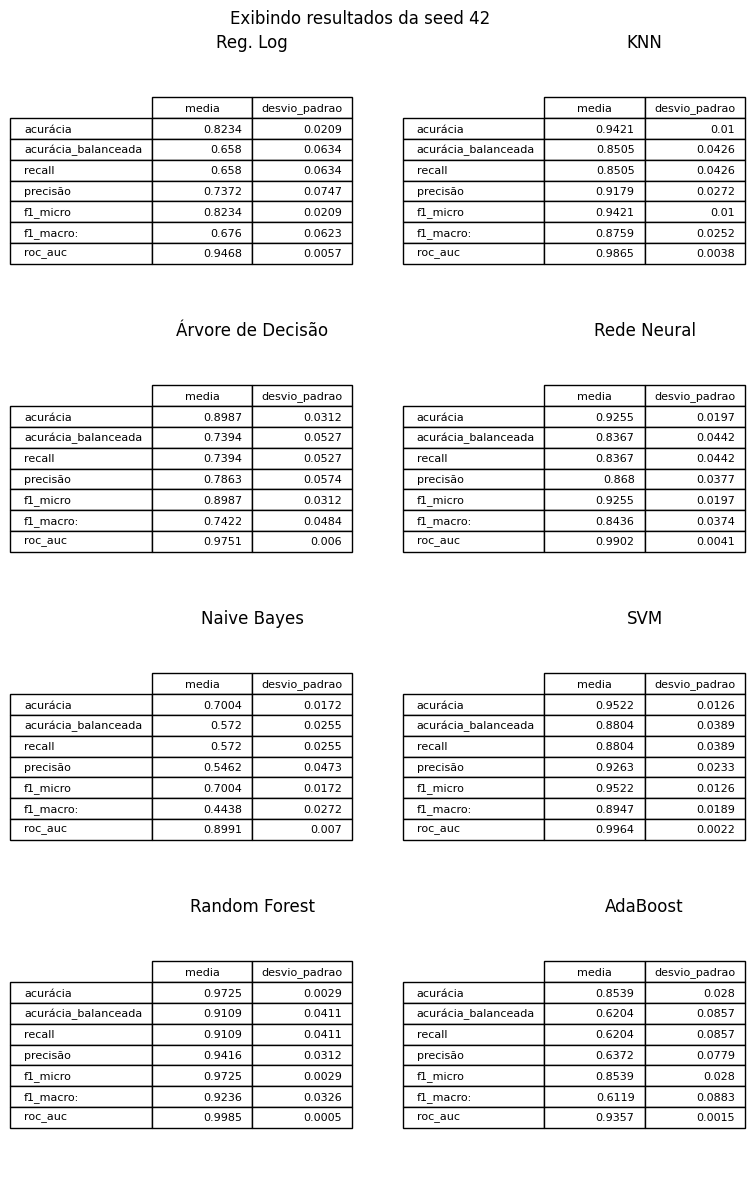

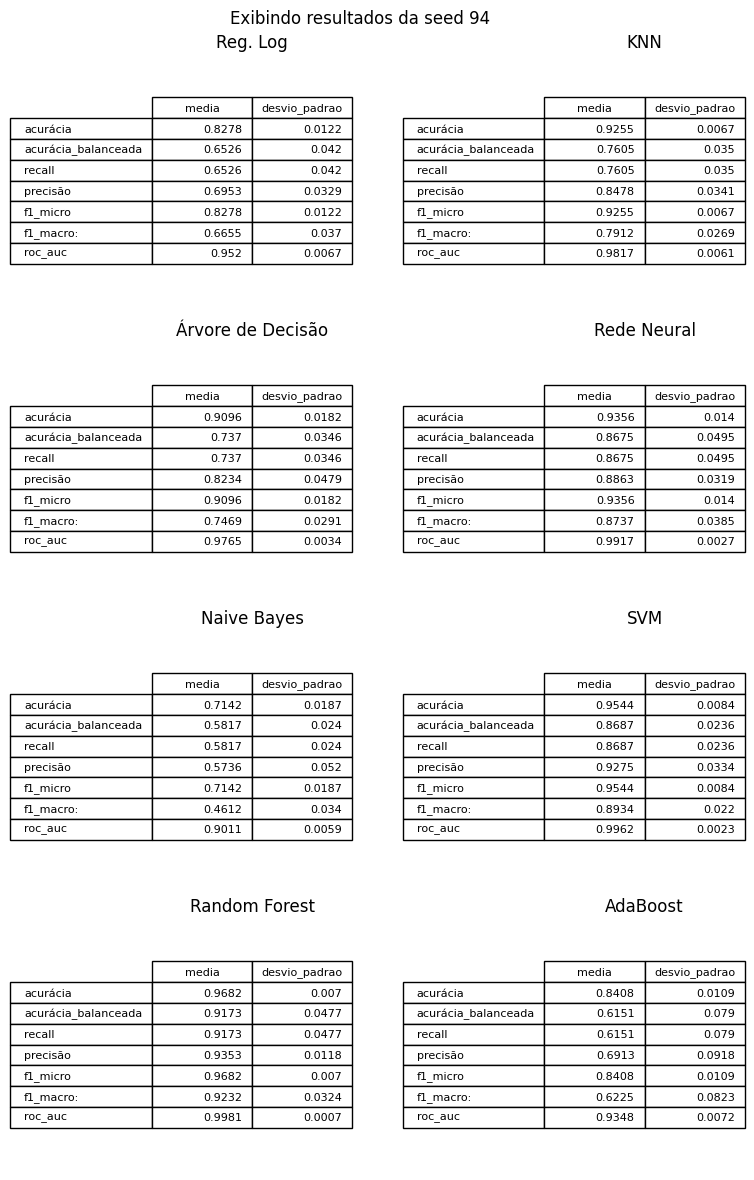

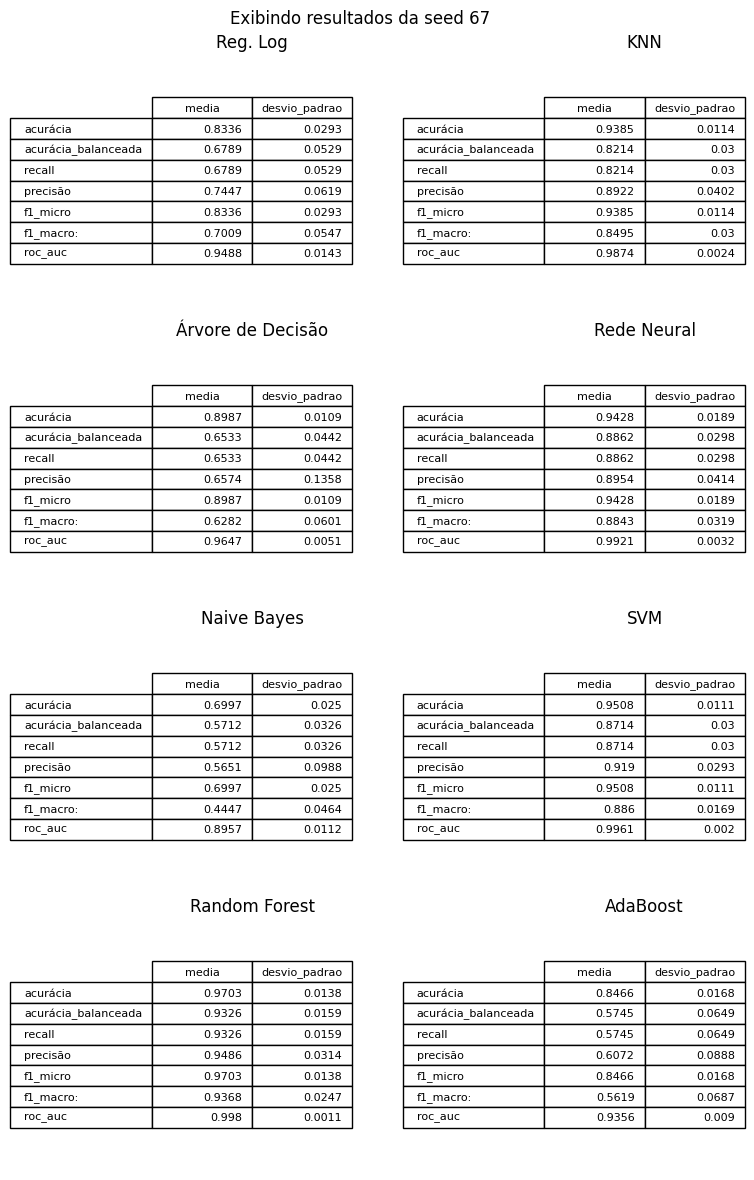

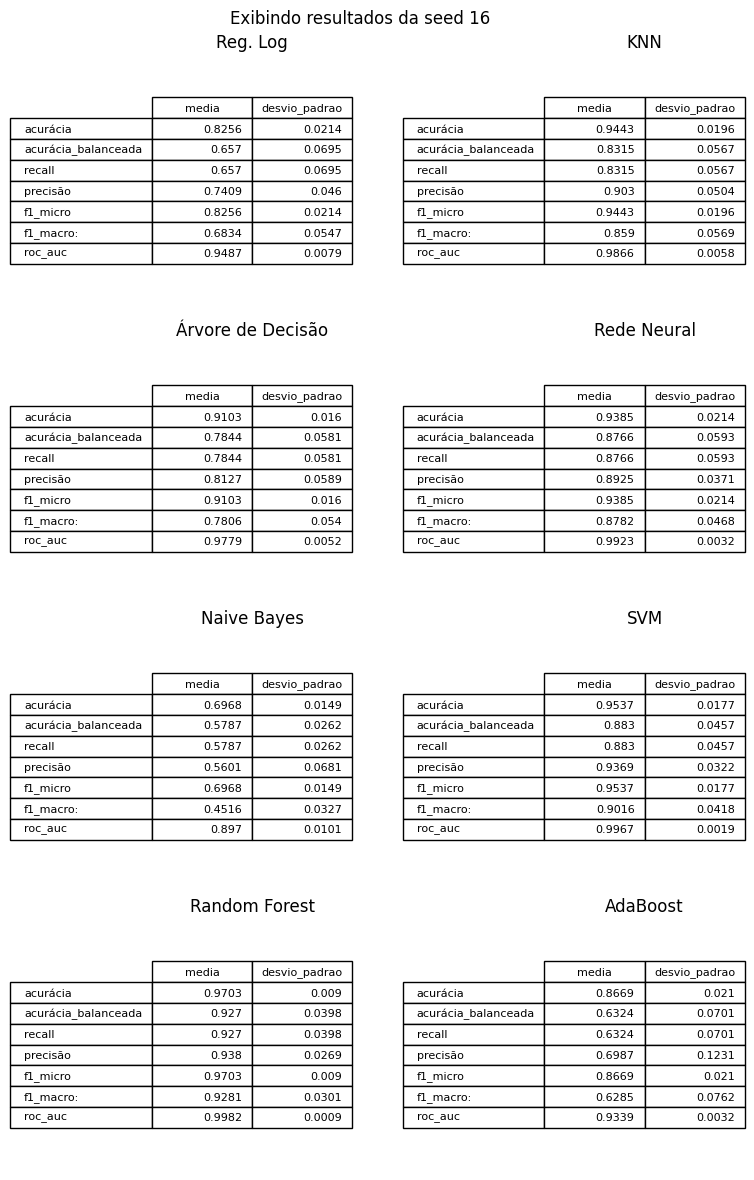

In [ ]:
from pandas.core.frame import DataFrame

testing = True # Booleana para testes, usada para desativar aviso de que a rede neural chegou no máximo de iterações sem convergir. Desativar no spot checking final

# Spot checking
scores_raw = [] # Os valores em cada seed, de cada algoritmo, para cada métrica
scores = { rng: {} for rng in RNG} # A média e desvio padrão em cada seed, de cada algoritmo, para cada métrica
y_tests = [] # Guarda os valores de 'y_test' de cada split (necessário para o gráfico de matriz de confusão)
y_preds = {nome: [] for nome in nomes_algoritmos} # Guarda os valores de 'y_pred' de cada modelo (necessário para o gráfico de matriz de confusão)
for i, rng in enumerate(RNG):
  scores_raw.append({})
  # Construção de algoritmos com hiperparâmetros fixos, apenas mudando a seed de rng, se for aplicável.
  algoritimos = {
      nomes_algoritmos[0]: LogisticRegression(random_state=rng, max_iter=200),
      nomes_algoritmos[1]: KNeighborsClassifier(n_neighbors=5),
      nomes_algoritmos[2]: DecisionTreeClassifier(max_depth=8, ccp_alpha=0.01, random_state=rng),
      nomes_algoritmos[3]: MLPClassifier(random_state=rng, max_iter=200), # com max_iter < 2000 não termina de convergir, mas se não tiver acima de 2000 ou não tiver demora MUITO tempo pra convergir totalmente (AUMENTAR NO SPOT FINAL)
      nomes_algoritmos[4]: GaussianNB(),
      nomes_algoritmos[5]: SVC(random_state=rng, probability=True),
      nomes_algoritmos[6]: RandomForestClassifier(random_state=rng),
      nomes_algoritmos[7]: AdaBoostClassifier(random_state=rng)
  }

  # Split treino/teste
  X_train, X_test, y_train, y_test = train_test_split(
      # Aqui y é transformado do formato Dataframe para um array unidimensional com .ravel()
      # Se não fizer isso, a função cross_val_score reclama
      X, y.values.ravel(), test_size=0.2, stratify=y.values.ravel(), random_state=rng
  )
  # Guardando conjunto de teste do split para uso na matriz de confusão
  y_tests.append(y_test)

  # Sem nested cross validation pois não faremos otimização de hiperparâmetros nessa etapa
  # Possivelmente mudar n_splits?
  cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=rng)
  # Testar a separação atual para cada algoritmo
  for nome_algoritmo, model in algoritimos.items():
    scores_raw[i][nome_algoritmo] = {}
    alg_score =  DataFrame(columns = ['media', 'desvio_padrao'])

    # Treino do modelo atual
    if testing:
      warnings.simplefilter("ignore", category=ConvergenceWarning) # Desativa o aviso de que a Rede Neural não convergiu (lembre de colocar testing = Flase quando for feito o spot final)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    # Guardando valores previstos pelo modelo nesse split para uso na matriz de confusão
    y_preds[nome_algoritmo].append(y_pred)
    for nome_metrica, metrica in metricas.items():
      # Testando o modelo para cada métrica com stratified-k-fold e guarrdando os scores
      score = cross_val_score(estimator=model, X=X_train, y=y_train, cv=cv, scoring=metrica)
      alg_score.loc[nome_metrica, 'media'] = round(float(score.mean()), 4)
      alg_score.loc[nome_metrica, 'desvio_padrao'] = round(float(score.std()), 4)
      scores_raw[i][nome_algoritmo][nome_metrica] = score
      #scores[i][nome_algoritmo][nome_metrica] =
      scores[rng][nome_algoritmo] = alg_score


ncols = 2 #numero escolhido de forma a deixar mais visível
nrows = 8 #numero escolhido de forma a deixar mais visível
plt_index = 0
for seed in scores.keys():

    fig, axes = plt.subplots(4, 2, figsize=(8, 12))
    axes = axes.flatten()
    for i, algoritmo in enumerate(scores[seed].keys()):
        df = scores[seed][algoritmo]
        axes[i].table(
            cellText=df.values,
            rowLabels=df.index,
            colLabels=df.columns,
            loc='center',
        )

        axes[i].set_title(algoritmo)
        axes[i].axis('off')

    fig.suptitle(f'Exibindo resultados da seed {seed}')
    plt.tight_layout()
    plt.show()
    plt.close(fig)




[{'Reg. Log': {'acurácia': array([0.84476534, 0.81588448, 0.78623188, 0.83333333, 0.83695652]), 'acurácia_balanceada': array([0.72311701, 0.67536429, 0.56031427, 0.61148002, 0.71996174]), 'recall': array([0.72311701, 0.67536429, 0.56031427, 0.61148002, 0.71996174]), 'precisão': array([0.77862539, 0.71114159, 0.61172949, 0.83527427, 0.74936959]), 'f1_micro': array([0.84476534, 0.81588448, 0.78623188, 0.83333333, 0.83695652]), 'f1_macro:': array([0.74748457, 0.69081415, 0.5824839 , 0.62807417, 0.73121867]), 'roc_auc': array([0.95715845, 0.94675123, 0.94121949, 0.94180306, 0.94705237])}, 'KNN': {'acurácia': array([0.94223827, 0.94223827, 0.92391304, 0.94927536, 0.95289855]), 'acurácia_balanceada': array([0.86116725, 0.84474572, 0.79076236, 0.83419615, 0.92177624]), 'recall': array([0.86116725, 0.84474572, 0.79076236, 0.83419615, 0.92177624]), 'precisão': array([0.93360541, 0.89716214, 0.88805194, 0.96298022, 0.9076332 ]), 'f1_micro': array([0.94223827, 0.94223827, 0.92391304, 0.94927536, 

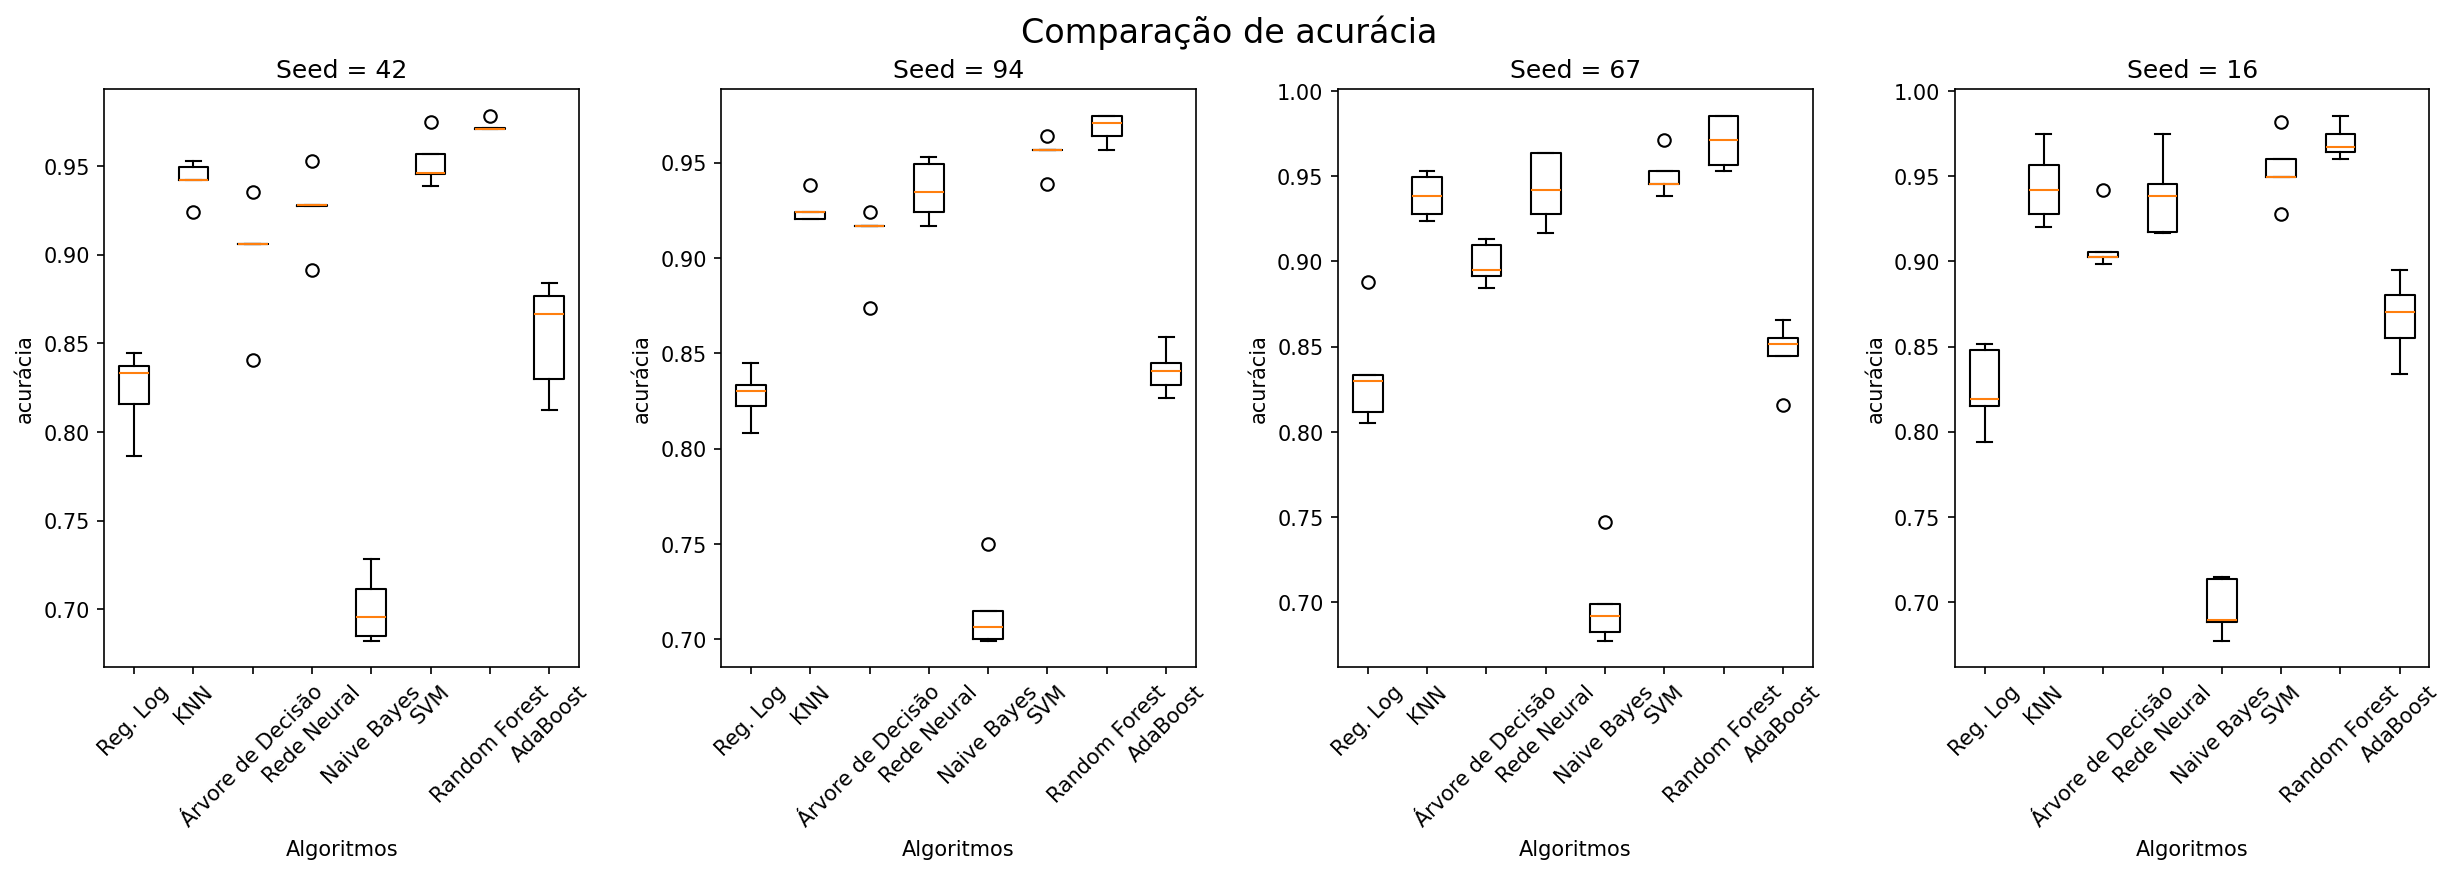

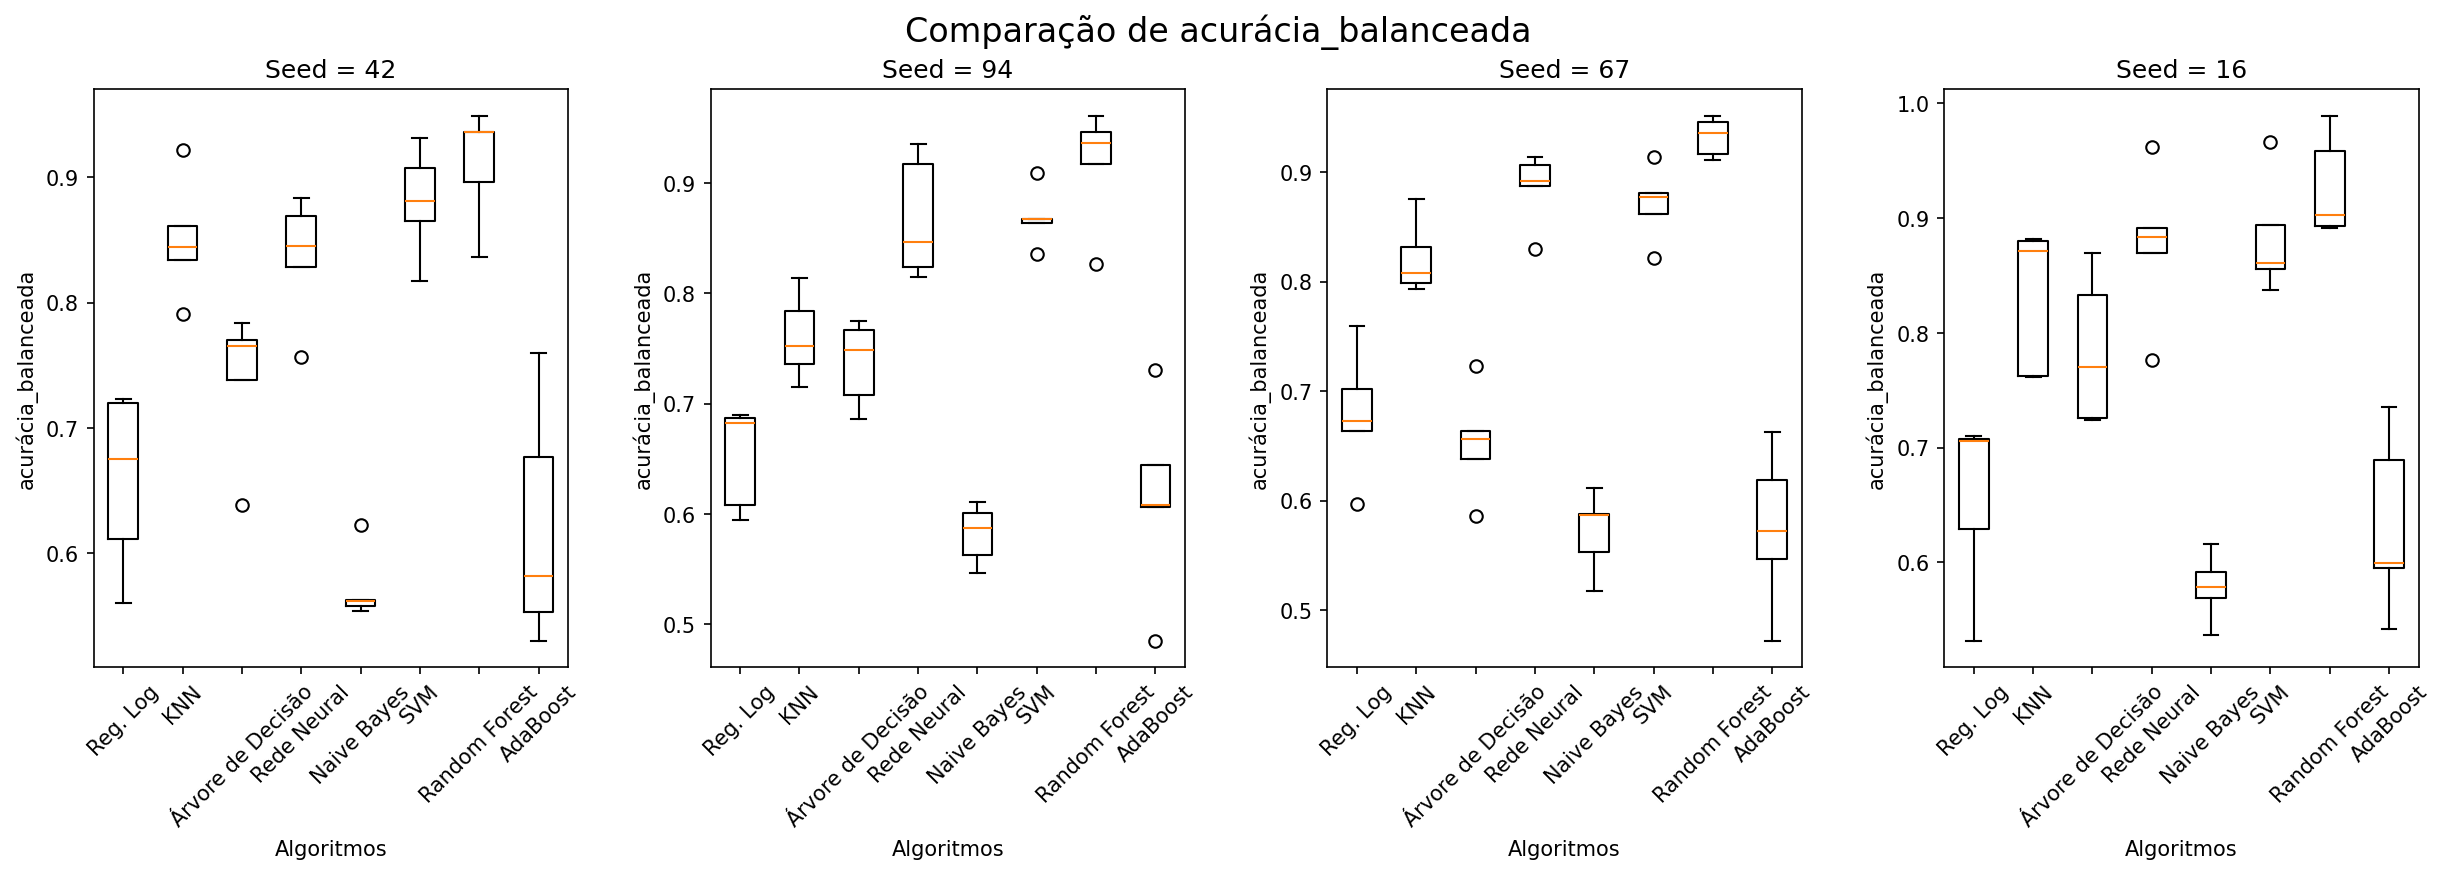

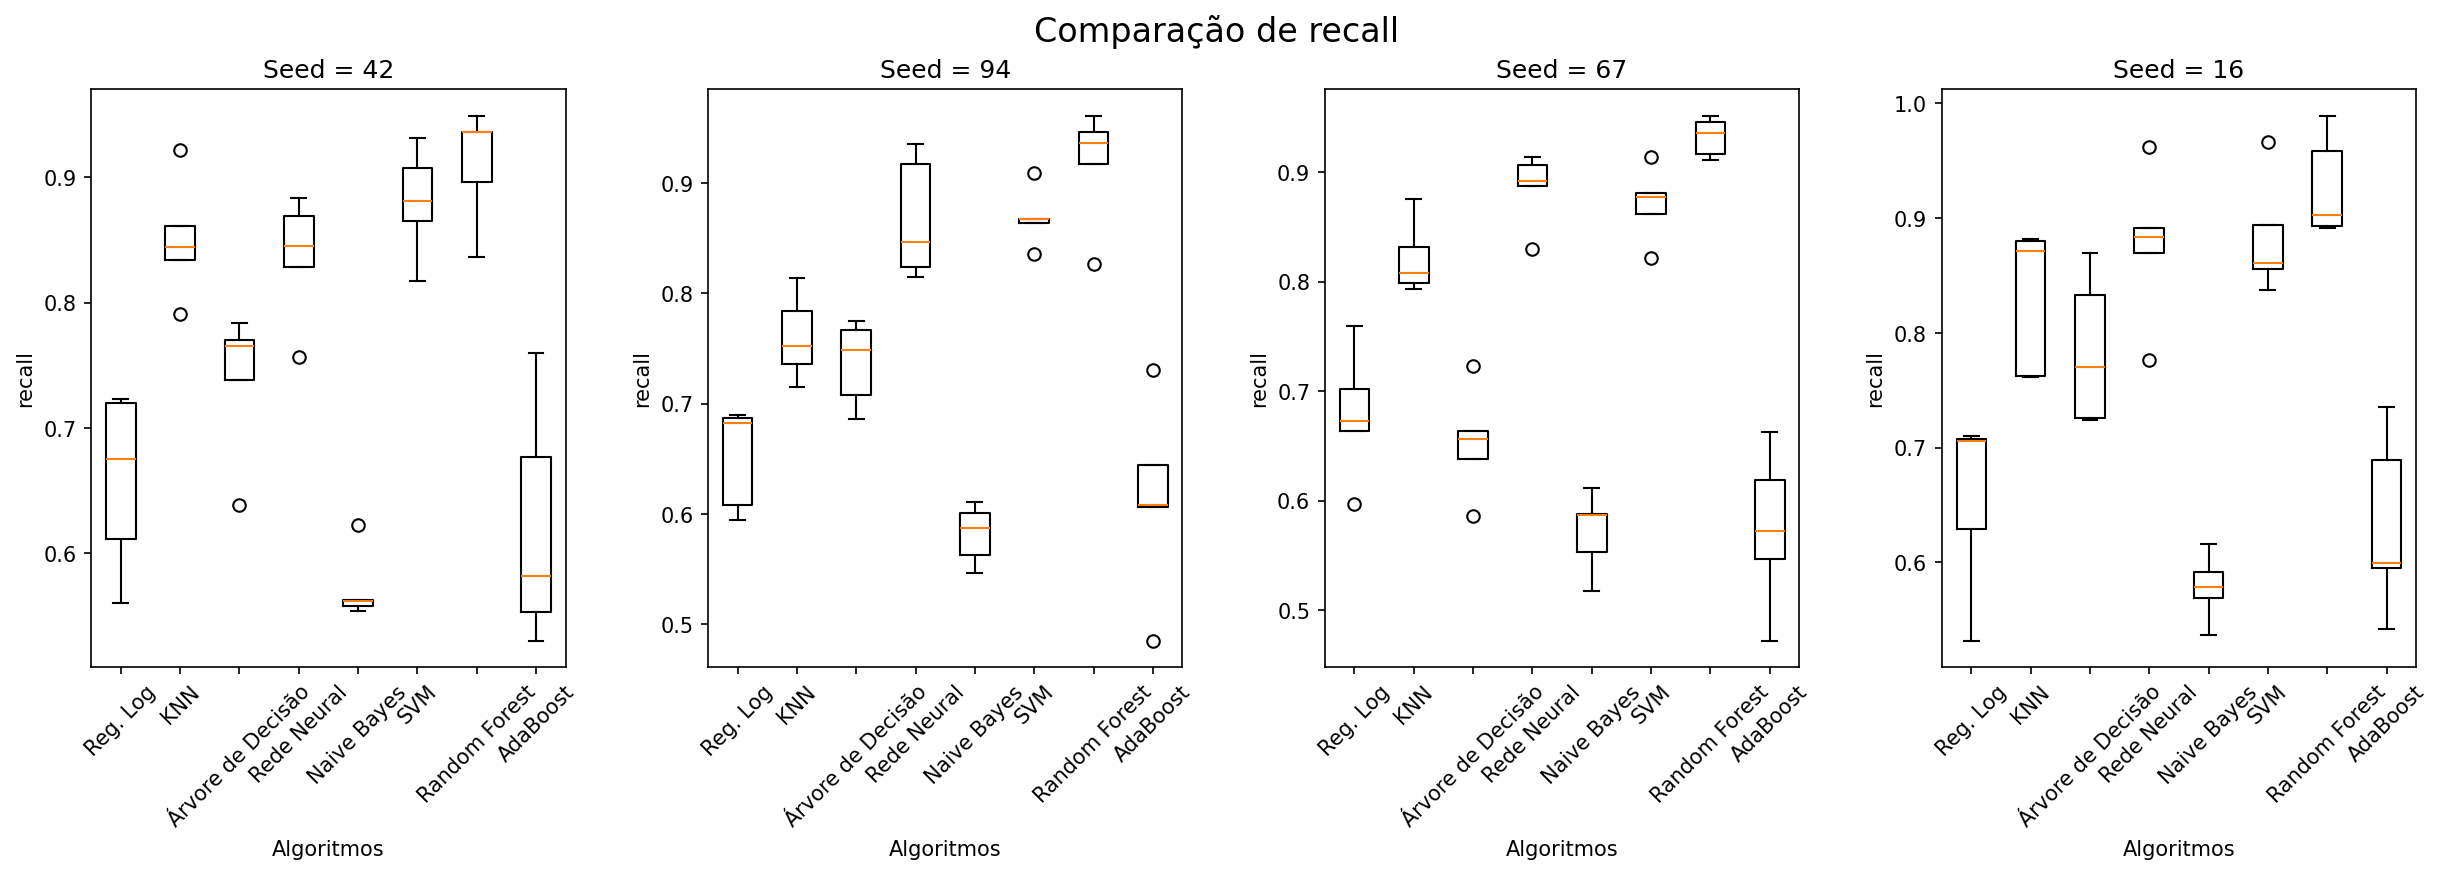

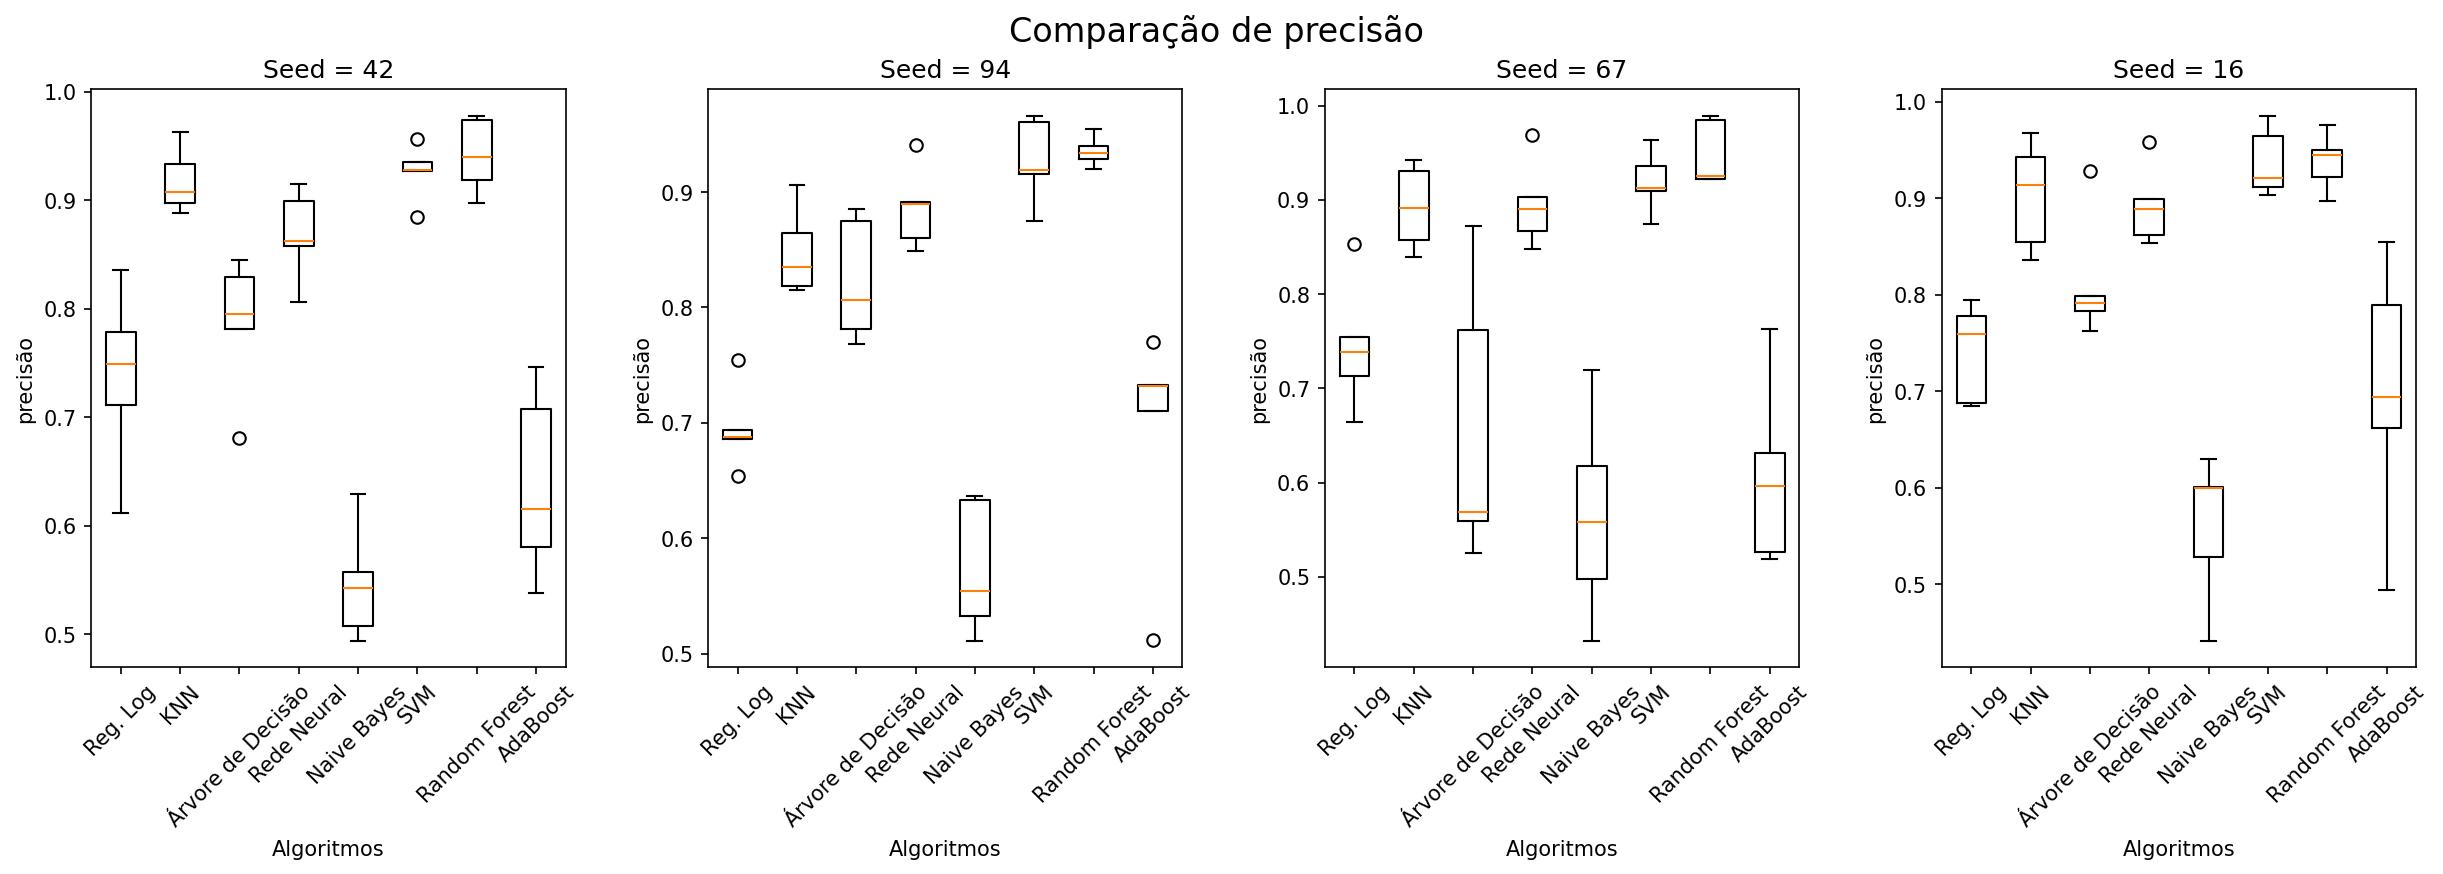

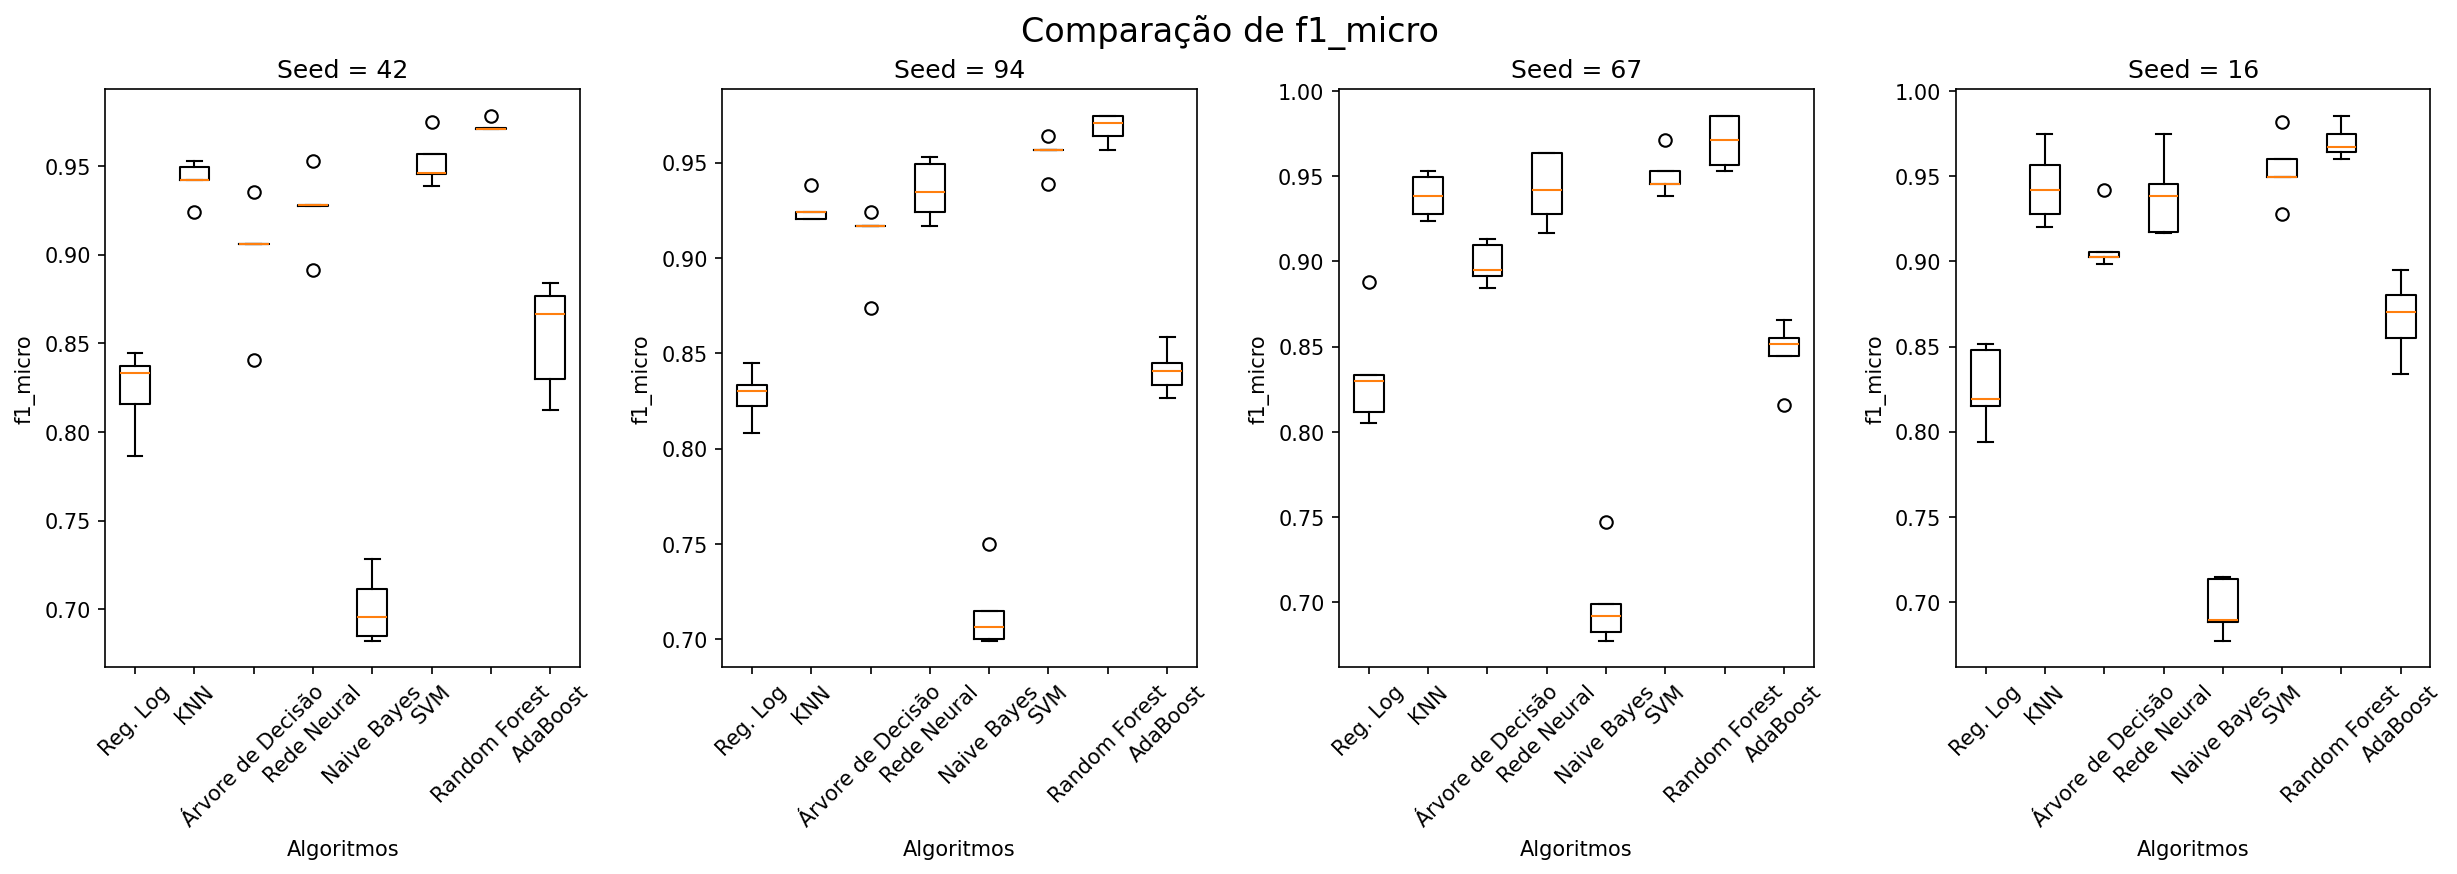

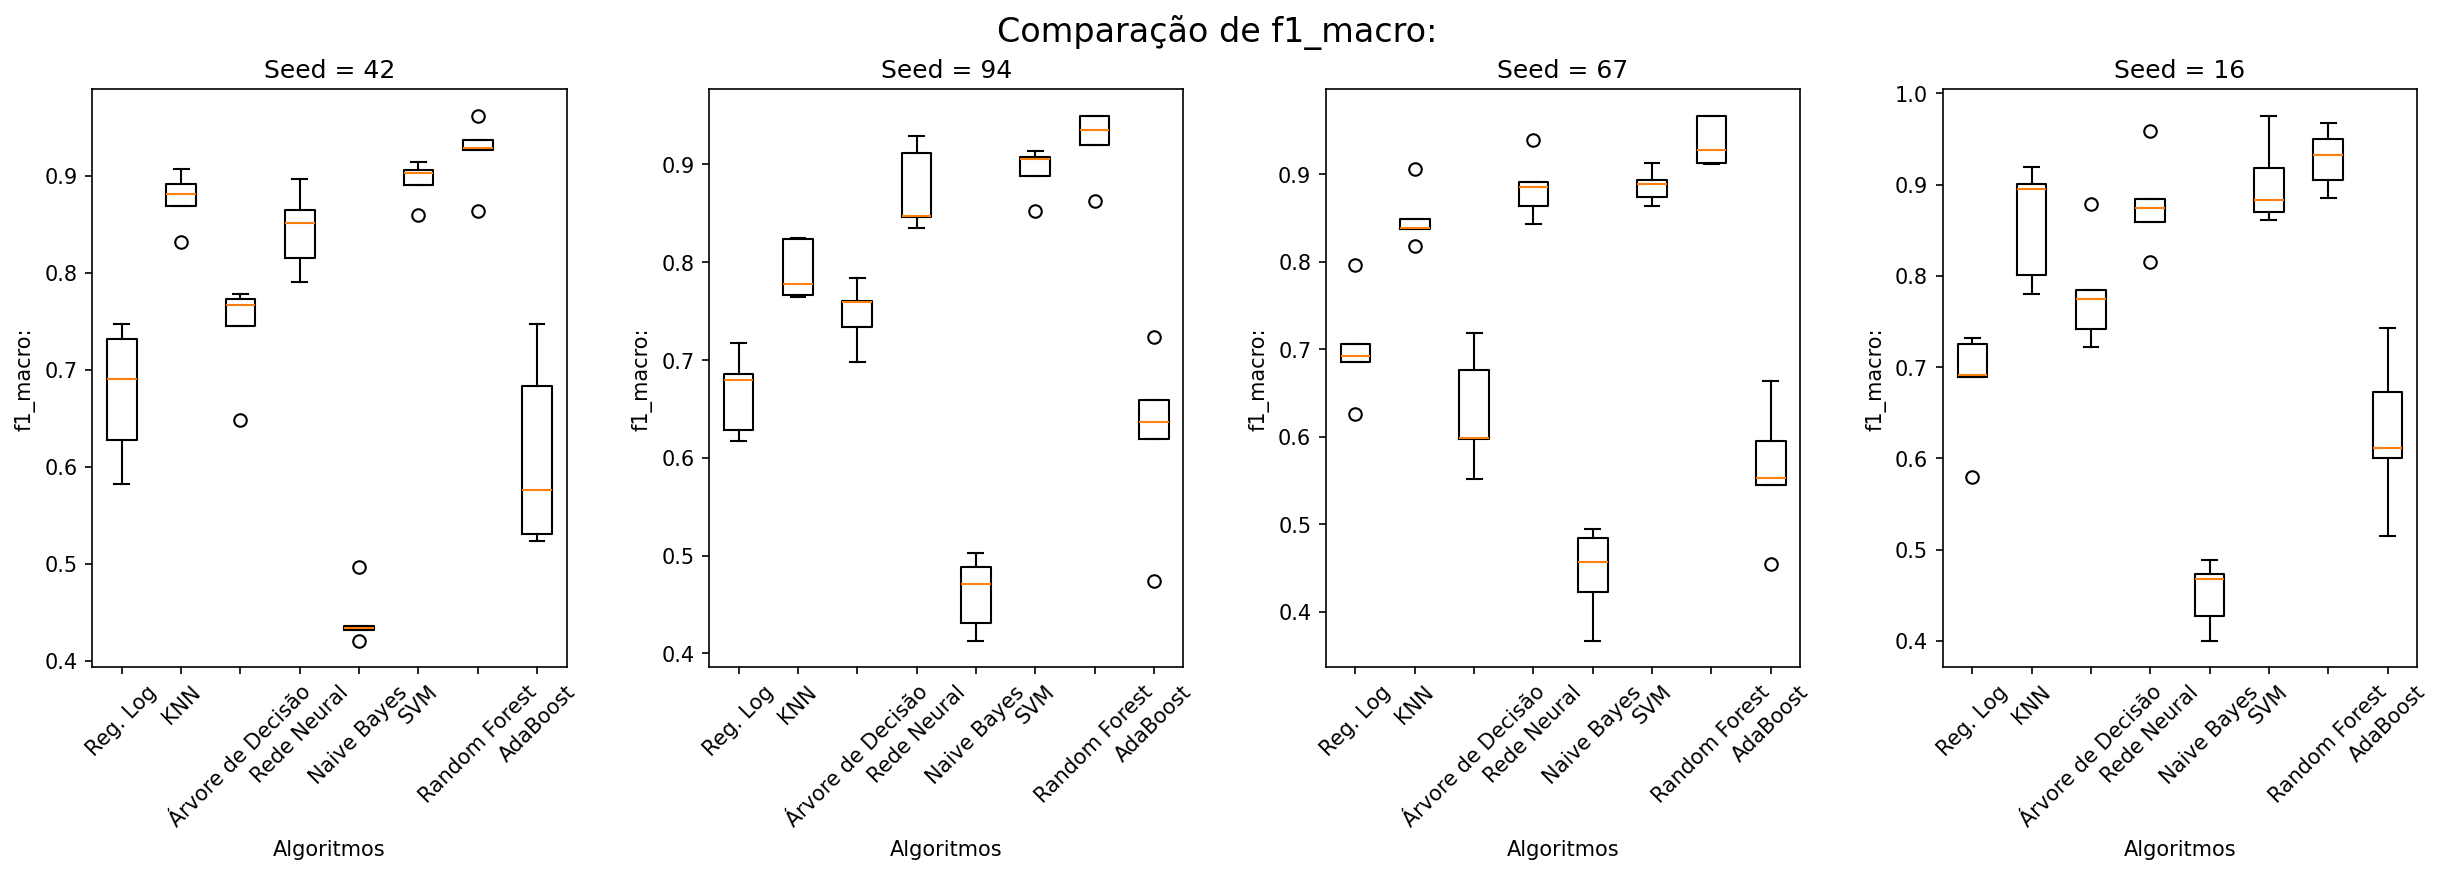

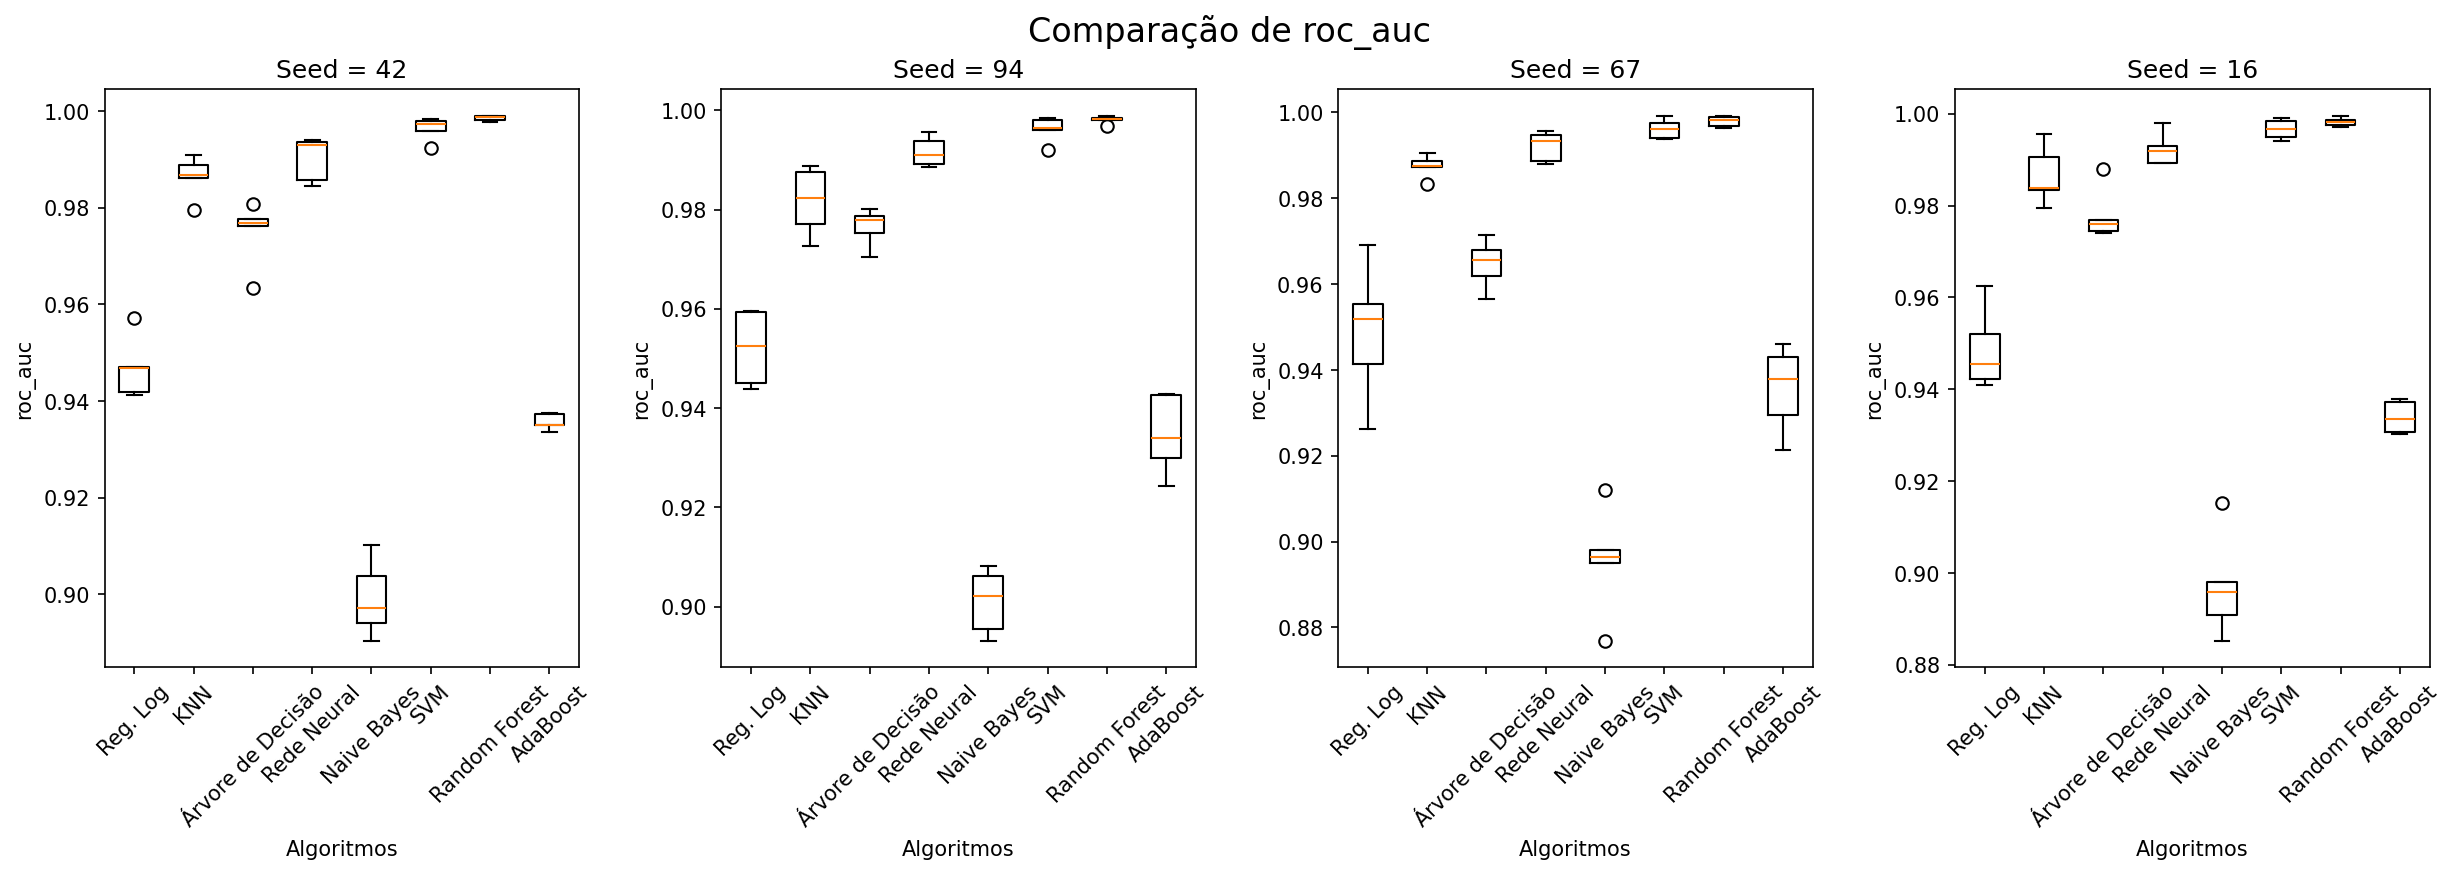

In [ ]:
# Box-Plots dos scores
# Uma coluna de gráficos para cada métrica, contendo len(RNG) gráficos comparando o desempenho de cada algoritmo em uma seed de RNG
num_seeds = len(RNG)
print(scores_raw)
plt.rcParams['figure.dpi'] = 150  # Melhora a resolução

for metrica in metricas.keys():
    fig, axes = plt.subplots(1, num_seeds, figsize=(5*num_seeds, 5))

    # Conserta as dimensões dos eixos se só temos uma seed
    if num_seeds == 1:
        axes = [axes]

    for i, seed in enumerate(RNG):
        ax = axes[i]

        data = []
        for nome in nomes_algoritmos:
            data.append(scores_raw[i][nome][metrica])

        ax.boxplot(data, tick_labels=nomes_algoritmos)
        ax.set_title(f"Seed = {seed}")
        ax.set_xlabel("Algoritmos")
        ax.set_ylabel(metrica)
        ax.tick_params(axis='x', rotation=45)

    fig.suptitle(f"Comparação de {metrica}", fontsize=16)
    plt.subplots_adjust(wspace=0.3)
    plt.show()

distribuição da classe good : 0.04046242774566474
distribuição da classe unacc : 0.6994219653179191
distribuição da classe acc : 0.22254335260115607
distribuição da classe vgood : 0.03757225433526012
['acc' 'good' 'unacc' 'vgood']
['acc' 'good' 'unacc' 'vgood']
Counter({'unacc': 1036, 'acc': 254, 'vgood': 50, 'good': 44}) Counter({'unacc': 968, 'acc': 308, 'good': 56, 'vgood': 52})
['good' 'unacc' 'unacc' ... 'unacc' 'acc' 'unacc'] ['good' 'unacc' 'unacc' ... 'unacc' 'acc' 'good']
['acc' 'good' 'unacc' 'vgood']
['acc' 'good' 'unacc' 'vgood']
Counter({'unacc': 975, 'acc': 311, 'good': 63, 'vgood': 35}) Counter({'unacc': 968, 'acc': 308, 'good': 56, 'vgood': 52})
['good' 'unacc' 'unacc' ... 'unacc' 'acc' 'unacc'] ['good' 'unacc' 'unacc' ... 'unacc' 'good' 'unacc']
['acc' 'good' 'unacc' 'vgood']
['acc' 'good' 'unacc' 'vgood']
Counter({'unacc': 910, 'acc': 399, 'vgood': 48, 'good': 27}) Counter({'unacc': 968, 'acc': 308, 'good': 56, 'vgood': 52})
['good' 'unacc' 'unacc' ... 'unacc' 'acc' '

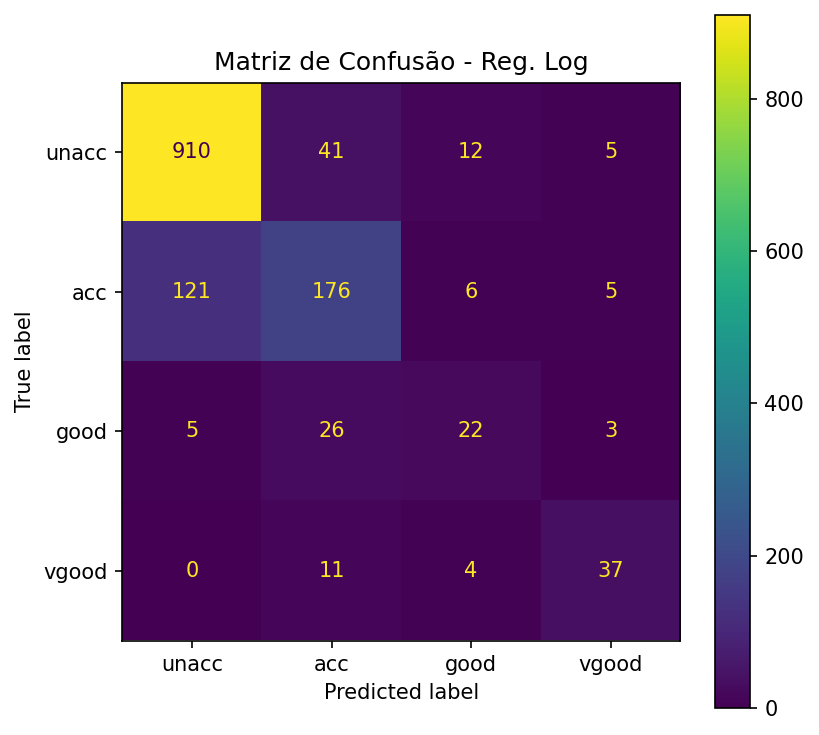

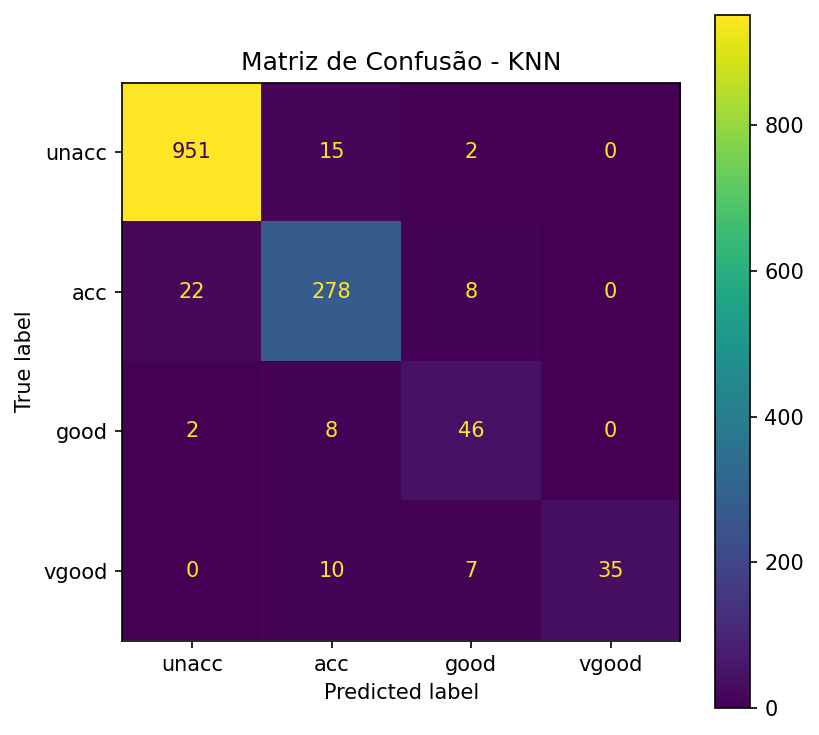

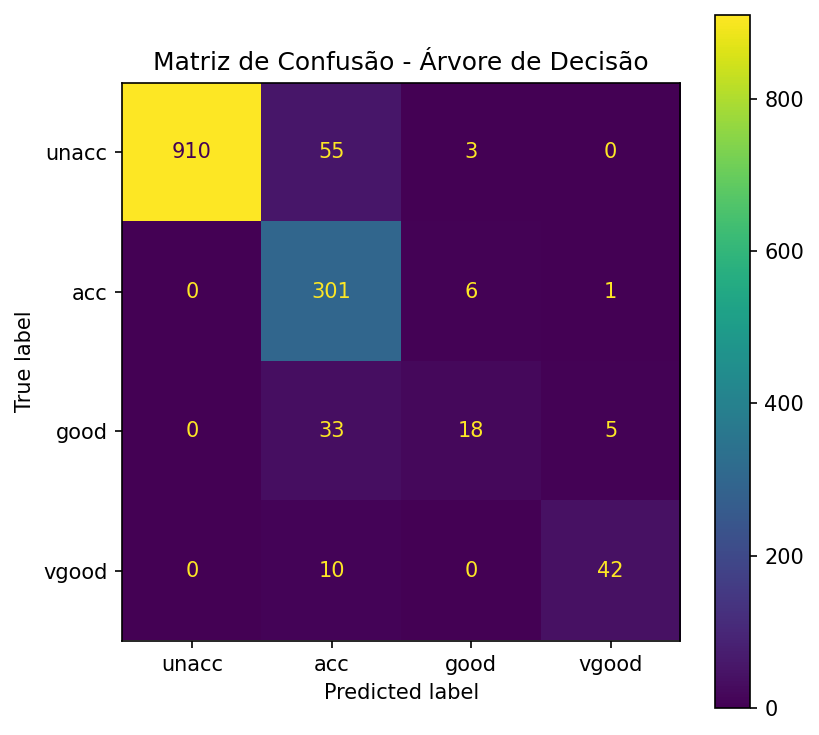

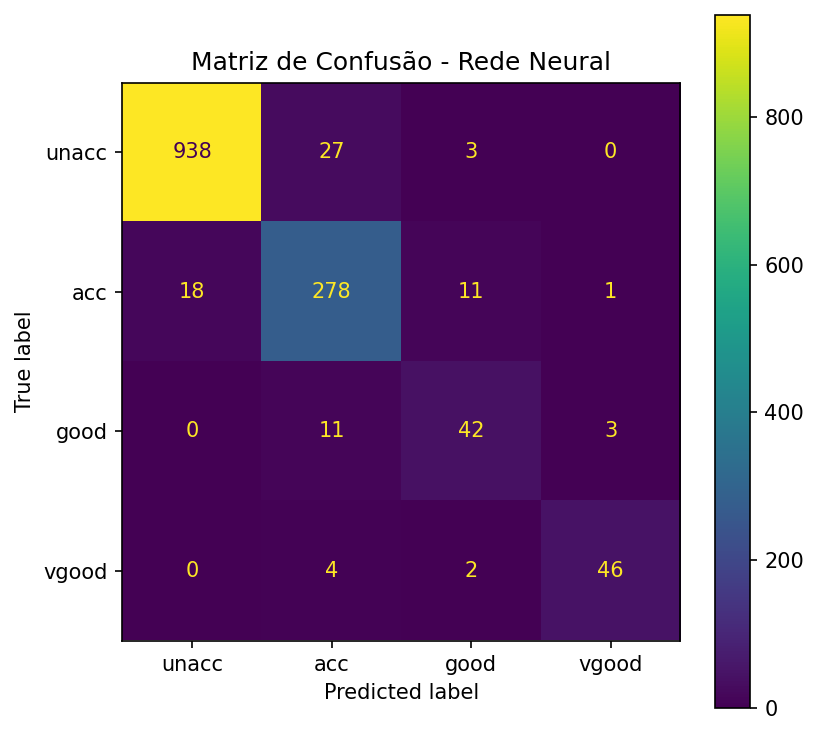

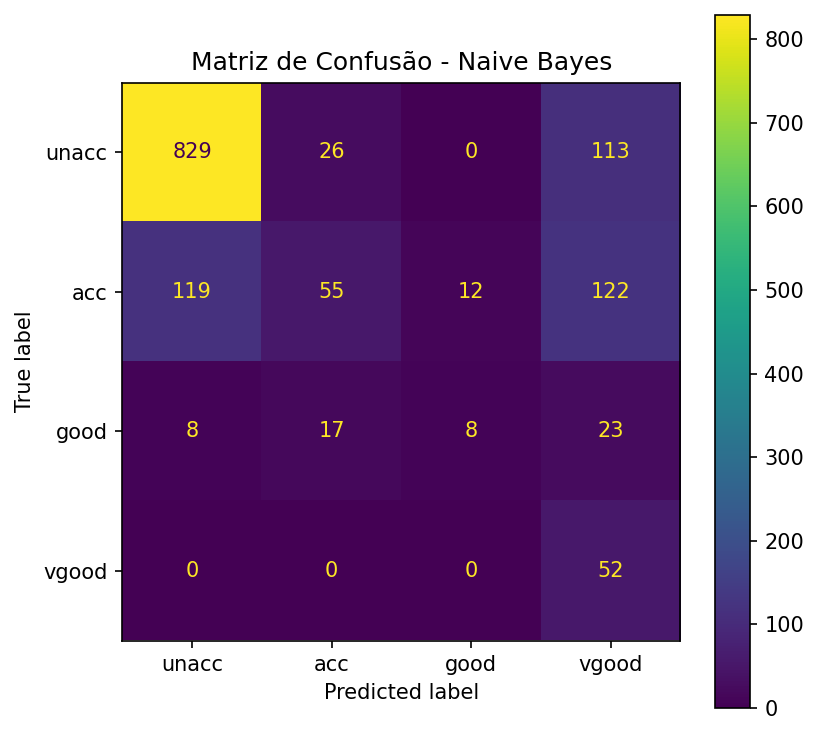

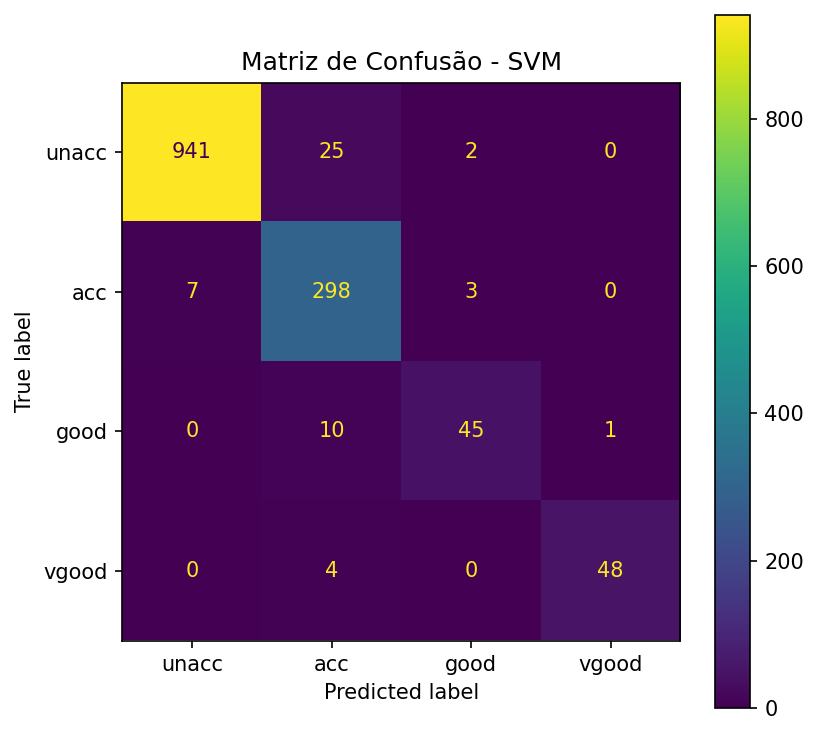

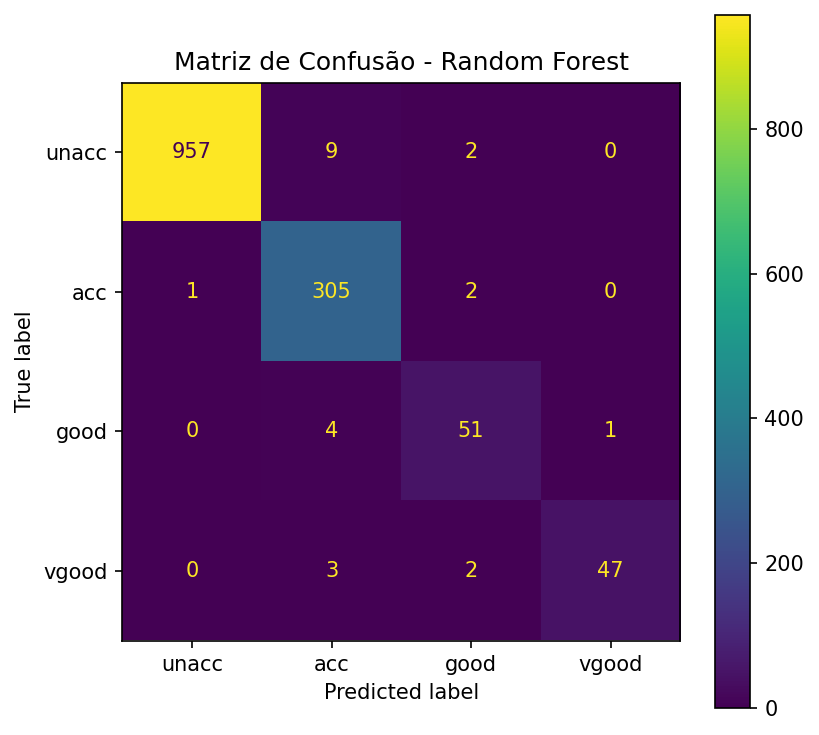

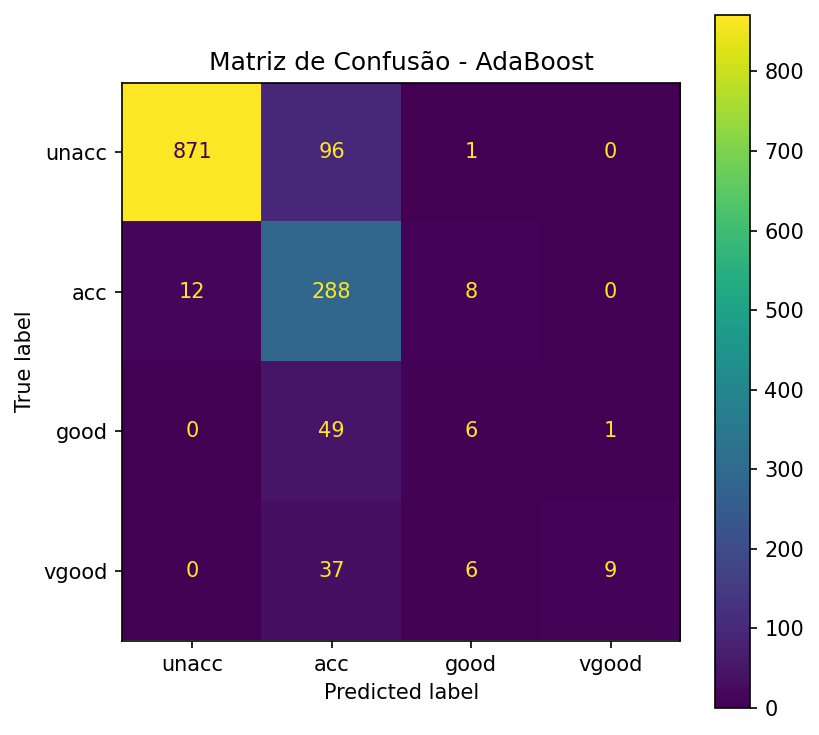

In [ ]:
# Matrizes de confusão das predições
from collections import Counter

nomes_classes = ["unacc", "acc", "good", "vgood"]
total_tests = Counter(np.concatenate(y_tests))
y_total =  sum(total_tests.values())
distr = {i: {j: 0 for j in nomes_classes} for i in nomes_algoritmos}
for i in total_tests.keys():
  print(f'distribuição da classe {i} : {total_tests[i] / y_total}')
for nome in nomes_algoritmos:
    y_tests_axis = np.concatenate(y_tests)
    y_pred_axis = np.concatenate(y_preds[nome])
    print(np.unique(y_tests_axis))
    print(np.unique(y_pred_axis))
    counting_test  =  Counter(y_pred_axis)
    total = sum(counting_test.values())
    print(counting_test, total_tests)
    print(y_tests_axis, y_pred_axis)
    for i in counting_test.keys():
      distr[nome][i] = (counting_test[i] / total) *100
      #print(f"distribuição da classe {i} predito no algoritmo {nome}: {counting_test[i] / total}")
    cm = confusion_matrix(y_pred= y_pred_axis, y_true=y_tests_axis, labels=nomes_classes)

    fig, ax = plt.subplots(figsize=(6,6))
    ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=nomes_classes).plot(ax=ax)
    ax.set_title(f"Matriz de Confusão - {nome}")
    #plt.show()
print(distr)